# Resampling Methods

Created on 2026-09-29

@author: Ruowen Xiao

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from numpy.polynomial import Polynomial

## Cross Validation

In [2]:
# load data
file_path_pollution = "./data/pollution_cleaneddata.csv"
df_pollution = pd.read_csv(file_path_pollution, sep=",")
df_pollution.head()

,PREC,JANT,JULT,OVR65,POPN,EDUC,HOUS,DENS,NONW,WWDRK,POOR,HC,NOX,SO@,HUMID,MORT
0,36.0,27.0,71.0,8.1,3.34,11.4,81.5,3243.0,8.8,42.6,11.7,21.0,15.0,59.0,59.0,921.870
1,35.0,23.0,72.0,11.1,3.14,11.0,78.8,4281.0,3.5,50.7,14.4,8.0,10.0,39.0,57.0,997.875
2,44.0,29.0,74.0,10.4,3.21,9.8,81.6,4260.0,0.8,39.4,12.4,6.0,6.0,33.0,54.0,962.354
3,47.0,45.0,79.0,6.5,3.41,11.1,77.5,3125.0,27.1,50.2,20.6,18.0,8.0,24.0,56.0,982.291
4,43.0,35.0,77.0,7.6,3.44,9.6,84.6,6441.0,24.4,43.7,14.3,43.0,38.0,206.0,55.0,1071.289


In [3]:
# polynomial regression model: y=MORT, x=JULT
poly_model = Polynomial.fit(df_pollution.JULT, df_pollution.MORT, deg=4)
poly_model.convert()

Polynomial([ 6.69462022e+04, -3.09175208e+03,  5.19940638e+01, -3.65038759e-01,
        8.66956469e-04], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

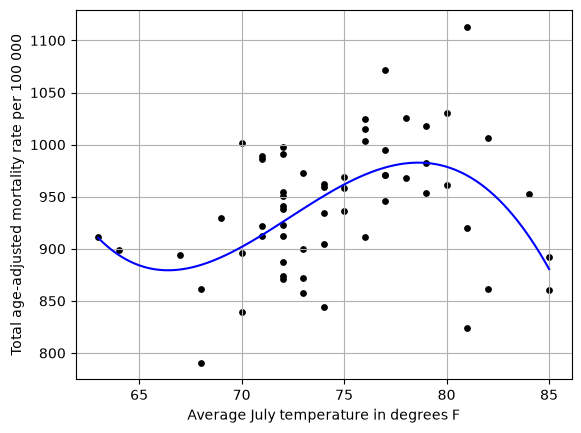

In [4]:
# plot
fig, ax = plt.subplots()
ax.scatter(df_pollution.JULT, df_pollution.MORT, s=15, c="black")

x = np.linspace(df_pollution.JULT.min(), df_pollution.JULT.max(), 100)
ax.plot(x, poly_model(x), color="blue")

ax.set_xlabel("Average July temperature in degrees F")
ax.set_ylabel("Total age-adjusted mortality rate per 100 000")
ax.grid()
plt.show()

### Validation set

In [5]:
# func: split data
def split(df, seed):
    n = len(df)
    rng = np.random.default_rng(seed=seed)

    train_idx = rng.choice(n, size=n // 2, replace=False)
    train = df.iloc[train_idx]

    test_idx = np.setdiff1d(np.arange(n), train_idx)
    test = df.iloc[test_idx]

    return train, test

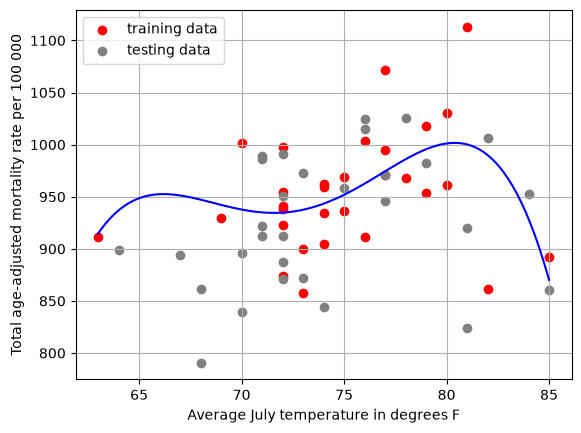

In [6]:
# visulization
seed = 921
train, test = split(df_pollution, seed)

fig, ax = plt.subplots()
ax.scatter(train.JULT, train.MORT, c="red", label="training data")
ax.scatter(test.JULT, test.MORT, c="gray", label="testing data")

poly_model = Polynomial.fit(x=train.JULT, y=train.MORT, deg=4)
x = np.linspace(train.JULT.min(), train.JULT.max(), 100)
ax.plot(x, poly_model(x), color="blue")

ax.legend()
ax.set_xlabel("Average July temperature in degrees F")
ax.set_ylabel("Total age-adjusted mortality rate per 100 000")
ax.grid()
plt.show()

In [7]:
# func: validation set
def validation_set(degrees, seed):
    variance_trains = []
    variance_tests = []

    for degree in degrees:
        train, test = split(df_pollution, seed=seed)
        x_train, y_train = train.JULT.to_numpy(), train.MORT.to_numpy()
        x_test, y_test = test.JULT.to_numpy(), test.MORT.to_numpy()

        poly_model = Polynomial.fit(x=x_train, y=y_train, deg=degree)

        y_train_pred = poly_model(x_train)
        mse_train = np.mean(np.square(y_train - y_train_pred))
        variance_trains.append(mse_train)

        y_test_pred = poly_model(x_test)
        mse_test = np.mean(np.square(y_test - y_test_pred))
        variance_tests.append(mse_test)

    return np.array(variance_trains), np.array(variance_tests)

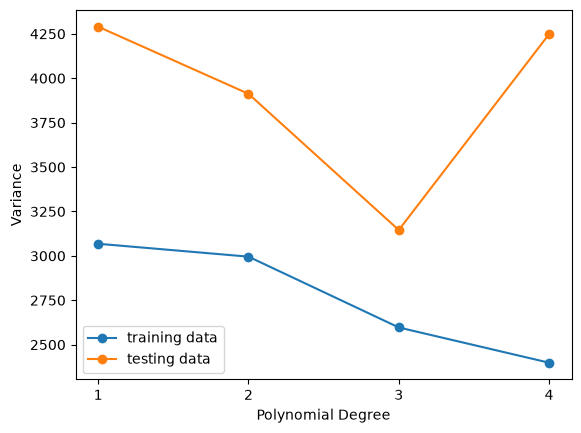

In [8]:
# plot variance-degree
degrees = range(1, 5)
variance_trains, variance_tests = validation_set(degrees, seed=seed)

fig, ax = plt.subplots()
ax.plot(degrees, variance_trains, marker="o", label="training data")
ax.plot(degrees, variance_tests, marker="o", label="testing data")

ax.legend()
ax.set_xticks(degrees)
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("Variance")
plt.show()

Judging from the variance-degree plot above, the polynomial of degree 3 has the minimum testing variance. Therefore, I would recommand to use the degree of 3 for the polynomial regression to have the smallest variance of new predictions.

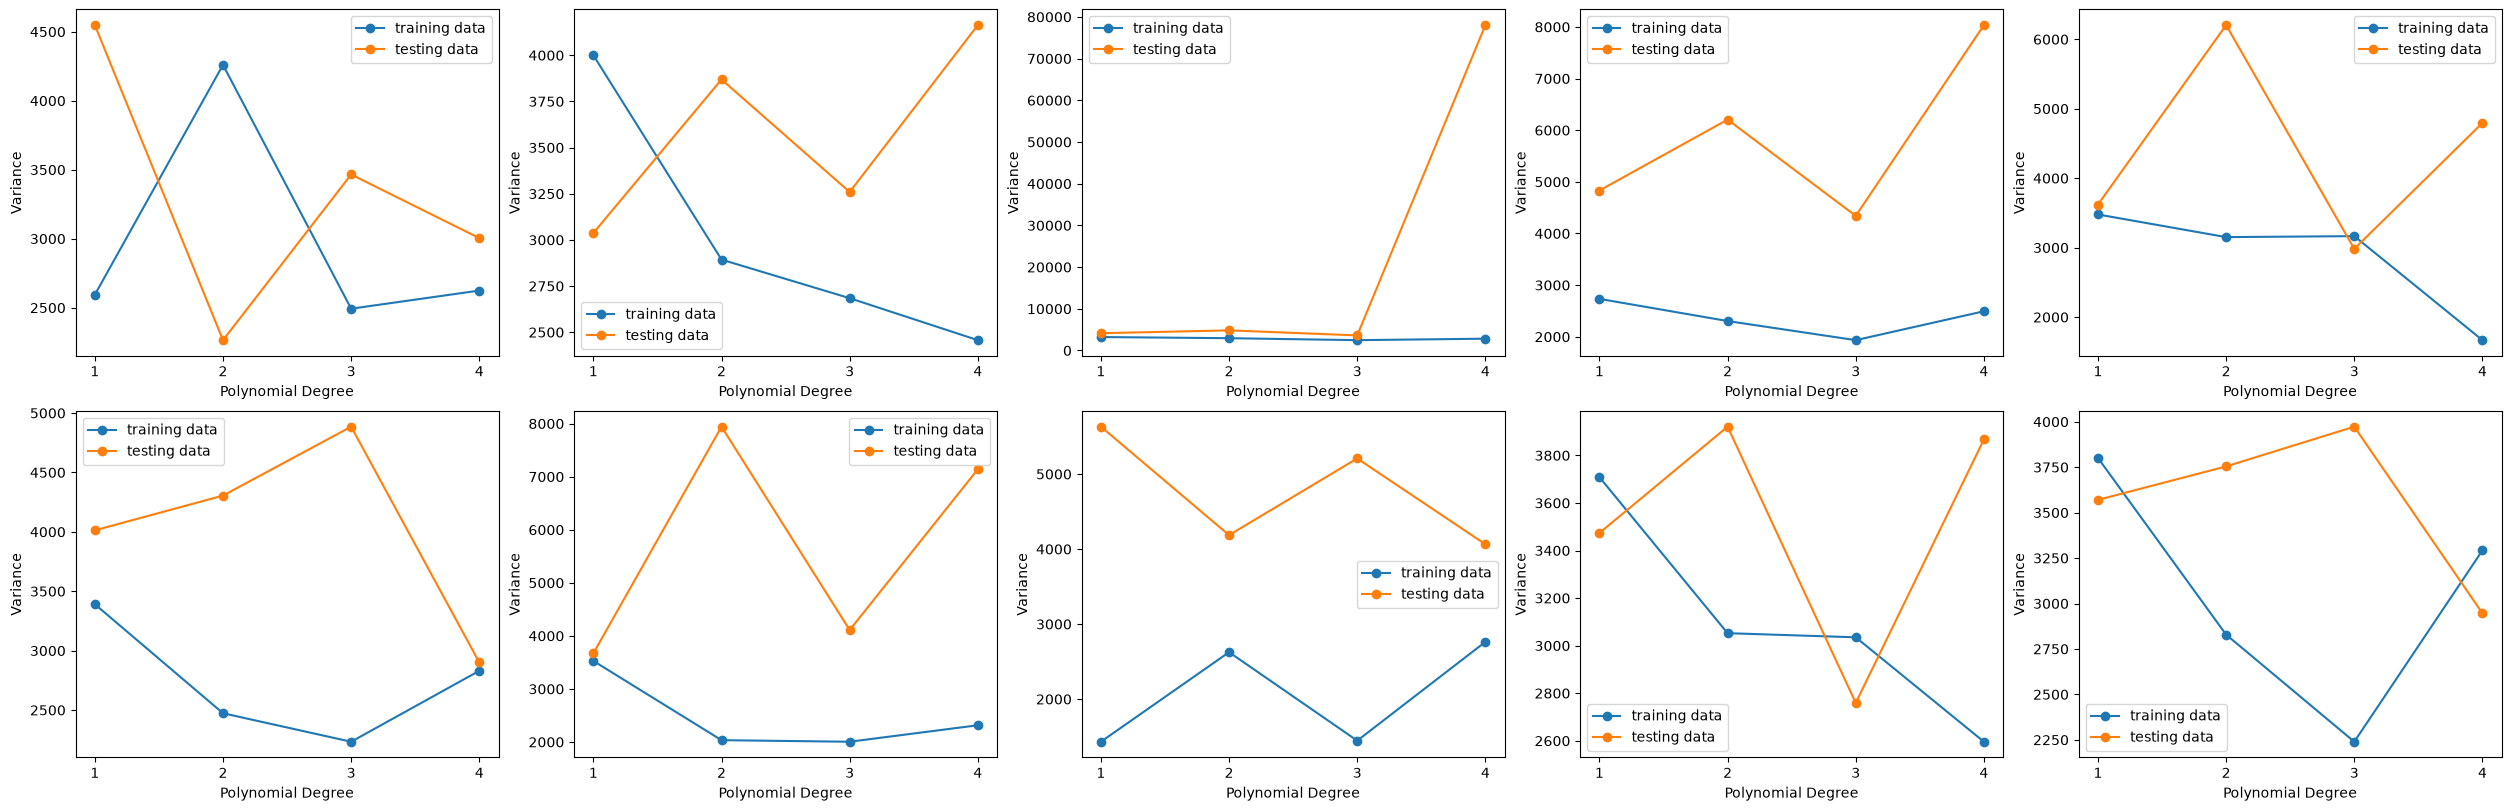

In [9]:
# repeat the procedure
fig, axes = plt.subplots(2, 5, figsize=(25, 8), constrained_layout=True)
for i, ax in enumerate(axes.flat):
    degrees = range(1, 5)
    variance_trains, variance_tests = validation_set(degrees, seed=None)

    ax.plot(degrees, variance_trains, marker="o", label="training data")
    ax.plot(degrees, variance_tests, marker="o", label="testing data")

    ax.legend()
    ax.set_xticks(degrees)
    ax.set_xlabel("Polynomial Degree")
    ax.set_ylabel("Variance")

plt.show()

By repeating the procedure 10 times, it shows that the estimated variance can change considerably for different splits into training and validation sets.

### K-fold cross validation

In [10]:
# func: split data into K sets
def split_k(df, k, seed):
    rng = np.random.default_rng(seed=seed)

    shuffled_idx = rng.permutation(len(df))
    folds = np.array_split(shuffled_idx, k)

    for i in range(k):
        test_idx = folds[i]
        test = df.iloc[test_idx]

        train_idx = np.concatenate([fold for j, fold in enumerate(folds) if j != i])
        train = df.iloc[train_idx]

        yield train, test

In [11]:
# func: K-fold cross validation
def k_fold(k, degree, seed):
    mse_trains = []
    mse_tests = []
    for train, test in split_k(df_pollution, k=k, seed=seed):
        x_train, y_train = train.JULT.to_numpy(), train.MORT.to_numpy()
        x_test, y_test = test.JULT.to_numpy(), test.MORT.to_numpy()

        poly_model = Polynomial.fit(x=x_train, y=y_train, deg=degree)

        y_train_pred = poly_model(x_train)
        mse_train = np.mean(np.square(y_train - y_train_pred))
        mse_trains.append(mse_train)

        y_test_pred = poly_model(x_test)
        mse_test = np.mean(np.square(y_test - y_test_pred))
        mse_tests.append(mse_test)

    return np.mean(mse_trains), np.mean(mse_tests)

def k_fold_with_degrees(k, degrees, seed):
    variance_trains = []
    variance_tests = []

    for degree in degrees:
        variance_train, variance_test = k_fold(k, degree, seed)
        variance_trains.append(variance_train)
        variance_tests.append(variance_test)

    return variance_trains, variance_tests

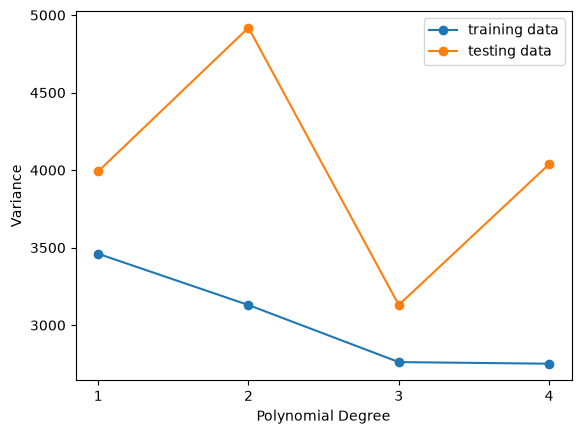

In [12]:
# plot mse-degree
k = 5
degrees = range(1, 5)
seed = 921

variance_trains, variance_tests = k_fold_with_degrees(k, degrees, seed)

fig, ax = plt.subplots()
ax.plot(degrees, variance_trains, marker="o", label="training data")
ax.plot(degrees, variance_tests, marker="o", label="testing data")

ax.legend()
ax.set_xticks(degrees)
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("Variance")
plt.show()

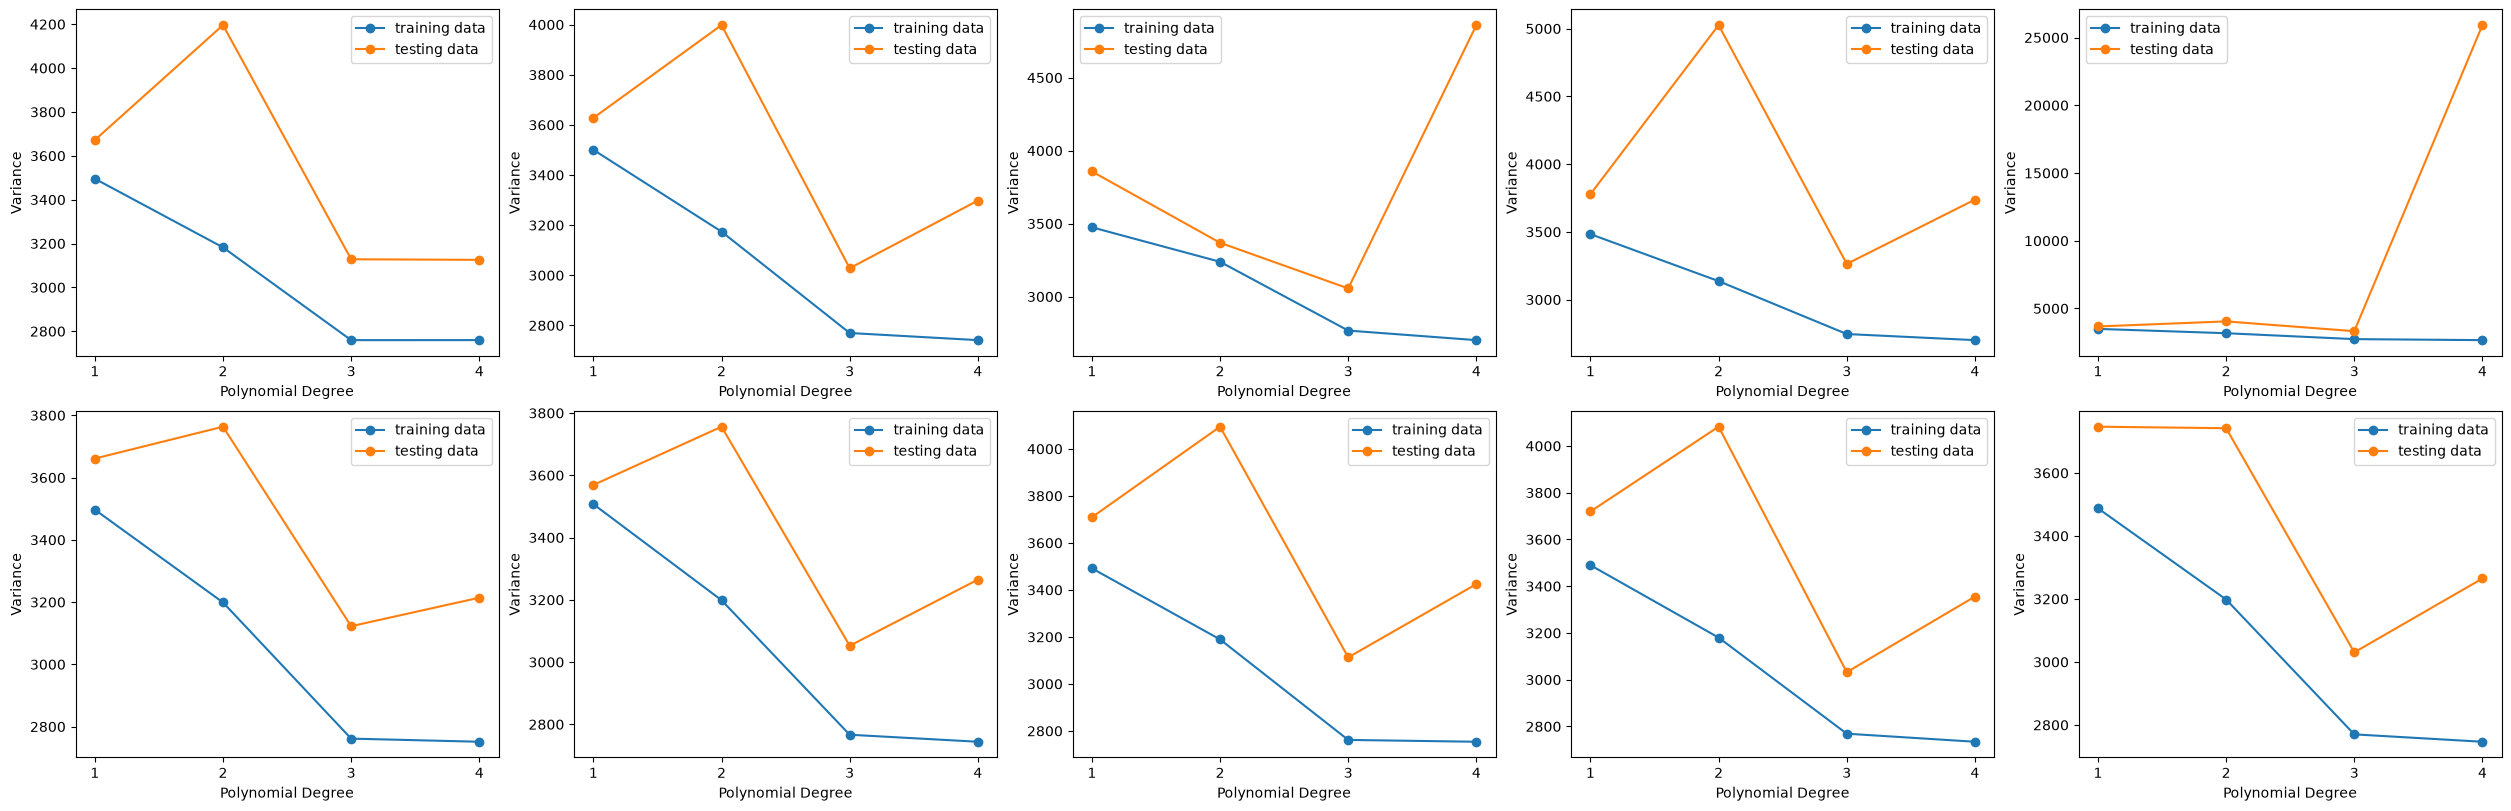

In [13]:
# repeat the procedure
fig, axes = plt.subplots(2, 5, figsize=(25, 8), constrained_layout=True)
for i, ax in enumerate(axes.flat):
    k = 5
    degrees = range(1, 5)
    variance_trains, variance_tests = k_fold_with_degrees(k, degrees, seed=None)

    ax.plot(degrees, variance_trains, marker="o", label="training data")
    ax.plot(degrees, variance_tests, marker="o", label="testing data")

    ax.legend()
    ax.set_xticks(degrees)
    ax.set_xlabel("Polynomial Degree")
    ax.set_ylabel("Variance")

plt.show()

We split the data into $K = 5$ sets and created the 10 variance-degree plots with random seeds. Most of the plots had the similar trends and had the lowest testing variances at the polynomial degree of 3.

K-fold cross validation trains data $K$ times and let every fold be validation once, then average the errors. Therefore, the results are less dependent on how the data was split.

## Bootstrap

In [14]:
# load data
file_path_bird = "./data/bird_count.csv"
df_bird = pd.read_csv(file_path_bird)
df_bird = df_bird.sort_values(by="yr")
df_bird.head()

,count,yr,observerAge,lineCov
10,10,1999,27,0.991667
6,5,2000,28,0.991667
11,9,2001,29,0.991667
2,12,2002,30,0.991667
9,14,2004,58,1.000000


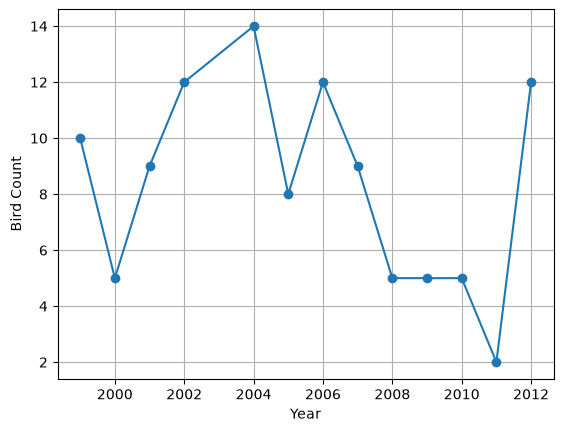

In [15]:
# plot data
fig, ax = plt.subplots()
ax.plot(df_bird["yr"], df_bird["count"], marker="o")

ax.set_xlabel("Year")
ax.set_ylabel("Bird Count")
ax.grid()
plt.show()

In [16]:
# fit model: Possion GLM
glm_model = smf.glm(
    formula="count ~ 1 + yr",
    data=df_bird,
    family=sm.families.Poisson()
)

result = glm_model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  count   No. Observations:                   13
Model:                            GLM   Df Residuals:                       11
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -34.683
Date:                Wed, 30 Sep 2026   Deviance:                       19.128
Time:                        01:27:20   Pearson chi2:                     18.5
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1387
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     67.1792     46.701      1.439      0.1

In [17]:
# bootstrap
n_samples = 1000
beta1_list = []
for _ in range(n_samples):
    sample = df_bird.sample(n=len(df_bird), replace=True)

    glm_model = smf.glm(
        formula="count ~ 1 + yr",
        data=sample,
        family=sm.families.Poisson()
    )
    result = glm_model.fit()
    beta1 = result.params["yr"]
    beta1_list.append(beta1)

beta1_list = np.array(beta1_list)
variance = np.sum(np.square(beta1_list - np.mean(beta1_list))) / (len(beta1_list) - 1)
se = math.sqrt(variance)

In [18]:
print(f"standard error: {se:.6f}")

standard error: 0.032550


Based on 1,000 bootstrap samples, the bootstrap standard error of the slope estimate is 0.032550.